# Four-City Kt — SARIMAX + XGBoost with Exogenous Predictors
### TCC · TCWV (ERA5) · ONI · IOD/DMI (NOAA / HadISST)

| Stage | What we do |
|-------|------------|
| 1 · Ingest | Load Kt, TCC, TCWV, ONI, DMI; align to common 1981–2025 MS index |
| 2 · CCF | Cross-correlation Kt anomaly vs each exogenous at lags −12 … +12, restricted to **causal** (≤ 0) lags when selecting the lag actually used as a feature |
| 3 · SARIMAX | Fit on train 1981–2015; **one-step-ahead walk-forward** forecast for 2016–2025, with the filter state (not the parameters) updated after each realised month |
| 4 · XGBoost | Same predictor set + lag-1, lag-12 Kt + harmonic month encoding (already one-step-ahead by construction, since the lag features use the realised Kt) |
| 5 · Evaluation | RMSE, climatology skill score, Diebold–Mariano test — now valid since both models are being scored on the same 1-month forecast horizon |

## 0 · Environment

In [2]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import pvlib
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import xgboost as xgb
from scipy import stats

warnings.filterwarnings("ignore")

In [4]:
from pathlib import Path

CITIES = {
    "Delhi":     (77.25, 28.50, 216),
    "Chennai":   (80.25, 13.00,   6),
    "Guwahati":  (91.75, 26.25,  51),
    "Jaisalmer": (70.75, 27.00, 225),
}

DATA_DIR = Path("data")

TRAIN_END  = "2015-12-01"
TEST_START = "2016-01-01"

SSRD_FILES = {c: DATA_DIR / f"{c.lower()}_monthly_ssrd_1981_2025.nc" for c in CITIES}
TCC_FILES  = {c: DATA_DIR / f"{c.lower()}_tcc_monthly_1981_2025.nc"  for c in CITIES}
TCWV_FILES = {c: DATA_DIR / f"{c.lower()}_tcwv_monthly_1981_2025.nc" for c in CITIES}

ONI_FILE = DATA_DIR / "oni.nc"
DMI_FILE = DATA_DIR / "dmi.had.long.nc"

## 1 · Data Ingest

In [6]:
IDX = pd.date_range("1981-01-01", "2025-12-01", freq="MS")


def to_series(da, idx):
    s = da.to_pandas()
    # Snap every timestamp to the first day of *its own* month, regardless
    # of what day-of-month the source file happens to use. The previous
    # `.normalize() + MonthBegin(0)` approach rolls any non-day-1 timestamp
    # forward into the *next* month, which would silently mislabel every
    # observation by one month if a source file isn't already day-1 stamped.
    s.index = pd.DatetimeIndex(s.index).to_period("M").to_timestamp()
    return s.reindex(idx)


def load_var(path, name):
    ds = xr.open_dataset(path)
    da = ds[name] if name in ds else ds[list(ds.data_vars)[0]]
    da = da.squeeze()
    da["time"] = pd.to_datetime(da.time)
    da.name = name
    return da


def load_ghi(path):
    da = load_var(path, "ssrd")
    da = da if da.name == "ssrd" else load_var(path, "surface_solar_radiation_downwards")
    da = da / 3600  # ERA5 hourly-accumulated J m^-2 -> W m^-2 (see sanity check below)
    da.name = "ghi"
    return da


def make_clear_ghi(lon, lat, alt):
    times = pd.date_range("1981-01-01", "2025-12-31 23:00", freq="h", tz="UTC")
    loc = pvlib.location.Location(lat, lon, altitude=alt, tz="UTC")

    s = (
        loc.get_clearsky(times, model="ineichen")["ghi"]
        .resample("MS")
        .mean()
    )
    s.index = s.index.tz_localize(None)

    return xr.DataArray(s, dims="time", coords={"time": s.index}, name="clear_ghi")


ghi       = {c: load_ghi(f) for c, f in SSRD_FILES.items()}
clear_ghi = {c: make_clear_ghi(*CITIES[c]) for c in CITIES}

kt = {c: ghi[c] / clear_ghi[c] for c in CITIES}
for x in kt.values():
    x.name = "Kt"

# Sanity check: a clearness index should sit roughly in [0, ~1.2-1.3].
# If the accumulation-period assumption above (hourly -> /3600) doesn't
# match the actual file convention (e.g. it's really a daily accumulation,
# which would need /86400 instead), Kt will be wildly off and this will
# flag it rather than letting it corrupt every downstream result silently.
for c, k in kt.items():
    vals = k.values
    vals = vals[~np.isnan(vals)]
    frac_in_range = np.mean((vals >= -0.05) & (vals <= 1.3))
    if frac_in_range < 0.95:
        warnings.warn(
            f"{c}: only {frac_in_range:.0%} of Kt values fall in the physically "
            "plausible [0, 1.3] range — check the SSRD accumulation-period "
            "assumption (divide by 3600 for hourly accumulation, 86400 for daily)."
        )

tcc  = {c: load_var(f, "tcc")  for c, f in TCC_FILES.items()}
tcwv = {c: load_var(f, "tcwv") for c, f in TCWV_FILES.items()}

oni = load_var(ONI_FILE, "value").sel(time=slice("1981-01", "2025-12"))
oni.name = "oni"

dmi = load_var(DMI_FILE, "value").sel(time=slice("1981-01", "2025-12"))
dmi.name = "dmi"

print("Kt:  ", {c: len(kt[c].time) for c in CITIES})
print("TCC: ", {c: len(tcc[c].time) for c in CITIES})
print("TCWV:", {c: len(tcwv[c].time) for c in CITIES})
print("ONI: ", len(oni.time))
print("DMI: ", len(dmi.time))

Kt:   {'Delhi': 540, 'Chennai': 540, 'Guwahati': 540, 'Jaisalmer': 540}
TCC:  {'Delhi': 540, 'Chennai': 540, 'Guwahati': 540, 'Jaisalmer': 540}
TCWV: {'Delhi': 540, 'Chennai': 540, 'Guwahati': 540, 'Jaisalmer': 540}
ONI:  540
DMI:  532


In [8]:
def anomalise(da, train_end=TRAIN_END):
    s = to_series(da, IDX)
    clim = s[:train_end].groupby(s[:train_end].index.month).mean()
    return s.groupby(s.index.month).transform(lambda x: x - clim[x.name])


EXOG_VARS = ["tcc_a", "tcwv_a", "oni", "dmi"]

EXOG_LABELS = {
    "tcc_a": "TCC anomaly",
    "tcwv_a": "TCWV anomaly",
    "oni":   "ONI",
    "dmi":   "DMI (IOD)",
}

df = {
    city: pd.DataFrame(
        {
            "kt":     to_series(kt[city], IDX),
            # kt_a now goes through the SAME train-only-climatology function
            # as tcc_a / tcwv_a (previously it used a full-record climatology
            # via a separate `kt_anomaly` block — a train/test leak; see
            # revision note #2 above).
            "kt_a":   anomalise(kt[city]),
            "tcc_a":  anomalise(tcc[city]),
            "tcwv_a": anomalise(tcwv[city]),
            "oni":    to_series(oni, IDX),
            "dmi":    to_series(dmi, IDX),
        },
        index=IDX,
    )
    for city in CITIES
}

print(df["Delhi"].head(3))
print(df["Delhi"].isna().sum())

                  kt      kt_a     tcc_a    tcwv_a   oni    dmi
1981-01-01  0.910839 -0.039406  0.014035  1.950464 -0.26 -0.201
1981-02-01  0.982955  0.037822 -0.031296 -0.318168 -0.50 -0.024
1981-03-01  0.916958 -0.050762  0.062947  2.116853 -0.47  0.027
kt        0
kt_a      0
tcc_a     0
tcwv_a    0
oni       0
dmi       8
dtype: int64


## 2 · Cross-Correlation Functions — Kt anomaly vs Exogenous

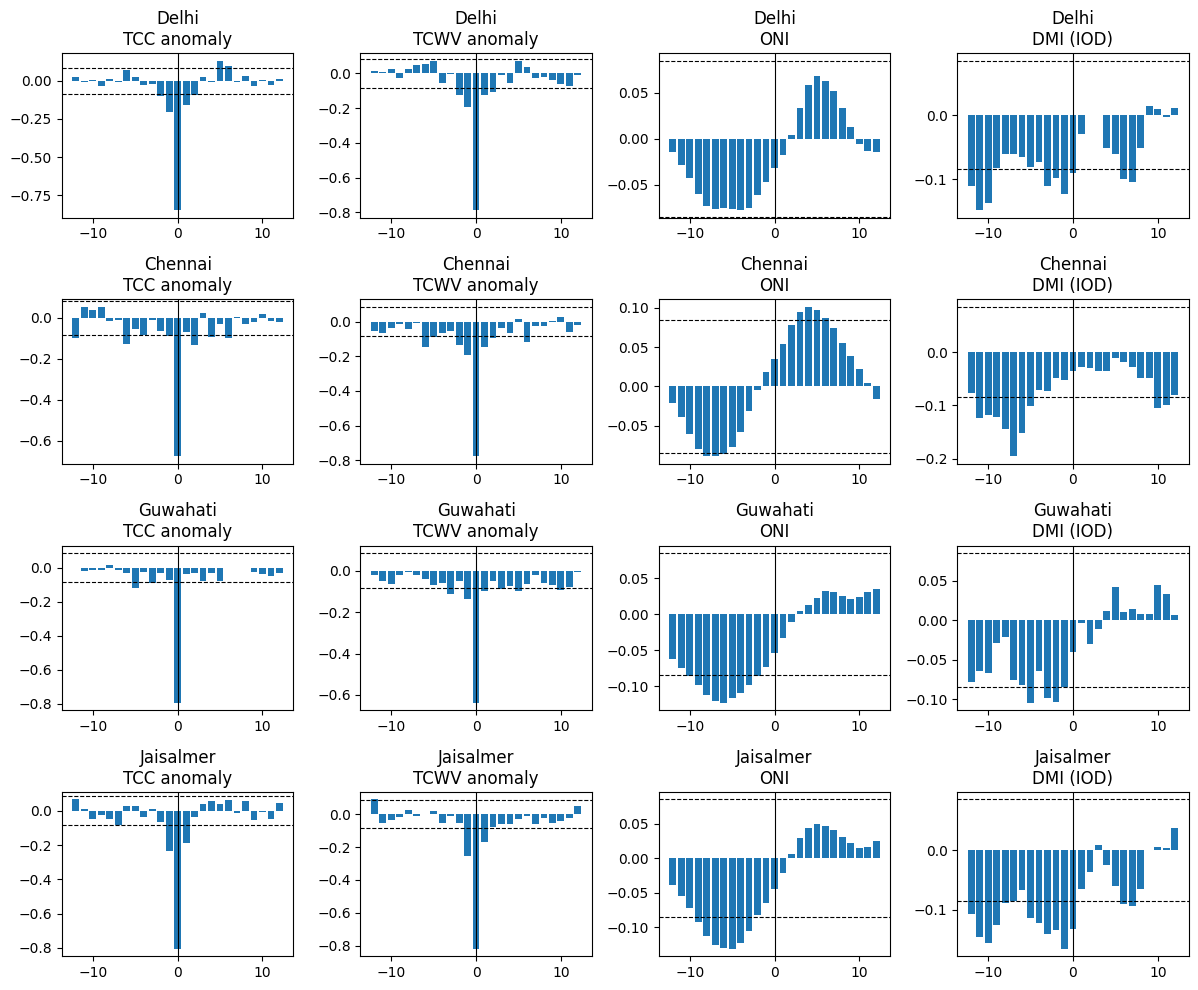

In [10]:
LAGS = np.arange(-12, 13)

ccf_results = {}

for city in CITIES:
    d = df[city].dropna()
    y = d["kt_a"].values

    ccf_results[city] = {
        var: np.array([
            np.corrcoef(
                y[max(0, -lag): len(y) - max(0, lag)],
                d[var].values[max(0, lag): len(y) - max(0, -lag)]
            )[0, 1]
            for lag in LAGS
        ])
        for var in EXOG_VARS
    }

fig, axes = plt.subplots(4, 4, figsize=(12, 10))

for i, city in enumerate(CITIES):
    n = len(df[city].dropna())
    ci = 1.96 / np.sqrt(n)  # per-city actual sample size, not the nominal 1981-2025 grid length
    for j, var in enumerate(EXOG_VARS):
        ax = axes[i, j]
        ax.bar(LAGS, ccf_results[city][var])
        ax.axhline(ci, ls="--", lw=0.8, color="k")
        ax.axhline(-ci, ls="--", lw=0.8, color="k")
        ax.axvline(0, lw=0.8, color="k")
        ax.set_title(f"{city}\n{EXOG_LABELS[var]}")

plt.tight_layout()
plt.show()

In [12]:
# With this CCF's convention, corr(y_t, x_{t+lag}) is maximised at lag = -L
# when "x from L months ago leads y now" — the only direction that is
# actually usable as a forecasting feature (the lag>0 side says y leads x,
# which would require knowing the *future* value of the exogenous driver).
# So we restrict the search for the "best" lag to lag <= 0 before picking
# the one we'll actually feed into the models.
print(f"{'City':10s}  {'TCC':>6}  {'TCWV':>6}  {'ONI':>6}  {'DMI':>6}")
print("-" * 42)

causal_mask = LAGS <= 0
causal_lags = LAGS[causal_mask]

opt_lags = {}

for city in CITIES:
    opt_lags[city] = {}
    row = []
    for var in EXOG_VARS:
        causal_corr = ccf_results[city][var][causal_mask]
        best = int(causal_lags[np.argmax(np.abs(causal_corr))])
        opt_lags[city][var] = best
        row.append(best)
    print(f"{city:10s}  {row[0]:>6}  {row[1]:>6}  {row[2]:>6}  {row[3]:>6}")

City           TCC    TCWV     ONI     DMI
------------------------------------------
Delhi            0       0      -4     -11
Chennai          0       0      -7      -7
Guwahati         0       0      -6      -5
Jaisalmer        0       0      -5      -1


## 3 · SARIMAX with Exogenous Predictors (TCC, TCWV, ONI, DMI)

In [14]:
SARIMA_ORDER = (1, 0, 1)
SARIMA_SEASONAL = (1, 1, 1, 12)


def build_exog(d, opt, vars_=EXOG_VARS):
    """
    opt[v] is the CCF-convention lag chosen above (always <= 0): a value of
    -L means "x at t-L correlates with y at t", i.e. x leads y by L months.
    To turn that into a usable feature we need x's value from L months ago
    aligned to row t — in pandas that's `x.shift(+L)`, i.e. `x.shift(-opt[v])`
    since opt[v] = -L. Passing opt[v] straight into .shift() (as the
    original notebook did) silently flips this: pandas' shift(k) brings the
    *future* backward when k is negative, so the model would be fed
    not-yet-observed exogenous values. See revision note #1 above.
    """
    return pd.DataFrame(
        {v: d[v].shift(-opt[v]) for v in vars_},
        index=d.index
    )


sarimax_results = {}

print(f"{'City':10s}{'MAE':>10}{'RMSE':>10}{'AIC':>12}{'Sig coefs':>12}")
print("-" * 58)

for city in CITIES:
    d = df[city].dropna()

    exog = build_exog(d, opt_lags[city]).dropna()
    y = d["kt"].reindex(exog.index)

    y_train, exog_train = y[:TRAIN_END], exog[:TRAIN_END]
    y_test, exog_test = y[TEST_START:], exog[TEST_START:]

    fit = SARIMAX(
        y_train,
        exog=exog_train,
        order=SARIMA_ORDER,
        seasonal_order=SARIMA_SEASONAL,
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit(disp=False)

    # --- walk-forward, one-step-ahead forecasting --------------------------
    # A single fit.forecast(120) call would project the model blindly and
    # unconditionally 10 years into the future, never seeing a single
    # realised Kt value in between — a much harder task than the one
    # XGBoost is solving below (its kt_lag1 / kt_lag12 features use the
    # *true* observed past Kt at every test row, making it effectively a
    # one-step-ahead forecaster). Comparing those two would be
    # apples-to-oranges. Instead we roll forward one month at a time:
    # forecast month t, reveal the actual Kt for month t, update the
    # Kalman filter *state* (not re-estimate the parameters — refit=False)
    # and move on to t+1. This mirrors a realistic monthly operational
    # forecast and puts both models on the same footing.
    state = fit
    preds = []
    for t in y_test.index:
        step_exog = exog_test.loc[[t]]
        fc = state.get_forecast(steps=1, exog=step_exog)
        preds.append(fc.predicted_mean.iloc[0])
        state = state.append(y_test.loc[[t]], exog=step_exog, refit=False)

    pred = pd.Series(preds, index=y_test.index)
    test_y = y_test

    mae = np.mean(np.abs(test_y - pred))
    rmse = mean_squared_error(test_y, pred) ** 0.5
    sig = (fit.pvalues < 0.05).sum()

    sarimax_results[city] = {
        "test": test_y,
        "pred": pred,
        "fit": fit,  # the original train-period fit (coefficients are never re-estimated during walk-forward)
    }

    print(f"{city:10s}{mae:10.4f}{rmse:10.4f}{fit.aic:12.2f}{sig:12d}")

City             MAE      RMSE         AIC   Sig coefs
----------------------------------------------------------
Delhi         0.0213    0.0275    -1640.35           3
Chennai       0.0268    0.0345    -1514.05           4
Guwahati      0.0305    0.0394    -1522.96           5
Jaisalmer     0.0160    0.0230    -1879.49           6


In [16]:
for city, res in sarimax_results.items():

    print(f"\n{'=' * 60}")
    print(city)
    print(f"{'=' * 60}")

    tbl = pd.DataFrame({
        "coef": res["fit"].params,
        "se":   res["fit"].bse,
        "z":    res["fit"].tvalues,
        "p":    res["fit"].pvalues,
    })

    tbl["sig"] = tbl["p"].apply(
        lambda p: "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    )

    print(tbl.round(4))


Delhi
            coef       se        z       p  sig
tcc_a    -0.3135   0.0185 -16.9556  0.0000  ***
tcwv_a   -0.0060   0.0006  -9.6700  0.0000  ***
oni      -0.0015   0.0014  -1.0207  0.3074     
dmi      -0.0093   0.0039  -2.3700  0.0178    *
ar.L1     0.1431   0.8158   0.1754  0.8607     
ma.L1    -0.2113   0.8131  -0.2599  0.7949     
ar.S.L12  0.0520   0.0501   1.0373  0.2996     
ma.S.L12 -0.9999  20.6514  -0.0484  0.9614     
sigma2    0.0007   0.0143   0.0485  0.9613     

Chennai
            coef      se        z       p  sig
tcc_a    -0.2012  0.0242  -8.3157  0.0000  ***
tcwv_a   -0.0083  0.0006 -14.4002  0.0000  ***
oni       0.0023  0.0022   1.0555  0.2912     
dmi      -0.0053  0.0064  -0.8149  0.4151     
ar.L1    -0.4112  2.8908  -0.1423  0.8869     
ma.L1     0.3978  2.9133   0.1366  0.8914     
ar.S.L12 -0.0012  0.0549  -0.0217  0.9827     
ma.S.L12 -0.9869  0.1223  -8.0674  0.0000  ***
sigma2    0.0010  0.0001   9.3829  0.0000  ***

Guwahati
            coef      se

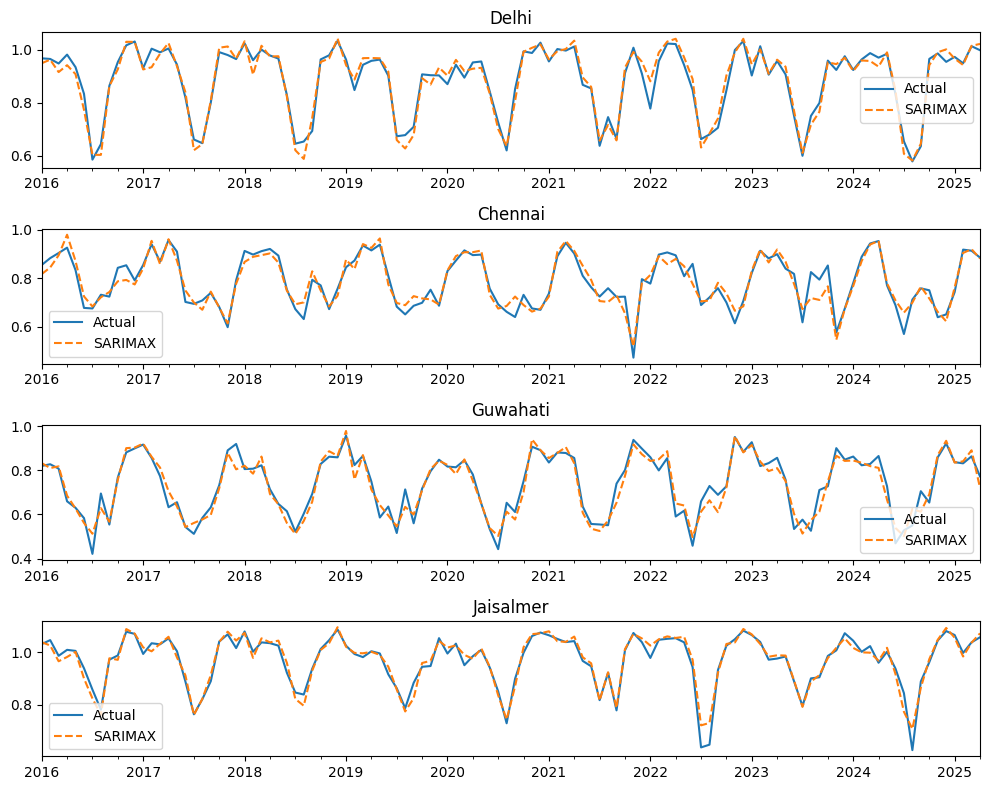

In [18]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8))

for ax, (city, res) in zip(axes, sarimax_results.items()):
    res["test"].plot(ax=ax, label="Actual")
    res["pred"].plot(ax=ax, ls="--", label="SARIMAX")
    ax.set_title(city)
    ax.legend()

plt.tight_layout()
plt.show()

## 4 · XGBoost — Identical Predictor Set

In [20]:
def build_feature_matrix(d, opt):
    feat = pd.DataFrame(index=d.index)

    # Same sign-correction as build_exog() above: opt[var] <= 0, and the
    # causal (past-looking) pandas shift is -opt[var].
    for var in EXOG_VARS:
        feat[var] = d[var].shift(-opt[var])

    feat["kt_lag1"] = d["kt"].shift(1)
    feat["kt_lag12"] = d["kt"].shift(12)
    feat["sin_month"] = np.sin(2 * np.pi * d.index.month / 12)
    feat["cos_month"] = np.cos(2 * np.pi * d.index.month / 12)

    return feat


xgb_results = {}

print(f"{'City':10s}{'MAE':>10}{'RMSE':>10}")
print("-" * 32)

for city in CITIES:
    d = df[city].dropna()

    feat = build_feature_matrix(d, opt_lags[city]).dropna()
    y = d["kt"].reindex(feat.index)

    model = xgb.XGBRegressor(
        n_estimators=400,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0,
    )

    model.fit(feat[:TRAIN_END], y[:TRAIN_END])

    y_test = y[TEST_START:]
    pred = pd.Series(
        model.predict(feat[TEST_START:]),
        index=y_test.index
    )

    mae = np.mean(np.abs(y_test - pred))
    rmse = mean_squared_error(y_test, pred) ** 0.5

    xgb_results[city] = {
        "test": y_test,
        "pred": pred,
        "model": model,
        "feat": feat,
    }

    print(f"{city:10s}{mae:10.4f}{rmse:10.4f}")

City             MAE      RMSE
--------------------------------
Delhi         0.0240    0.0330
Chennai       0.0292    0.0376
Guwahati      0.0296    0.0398
Jaisalmer     0.0195    0.0293


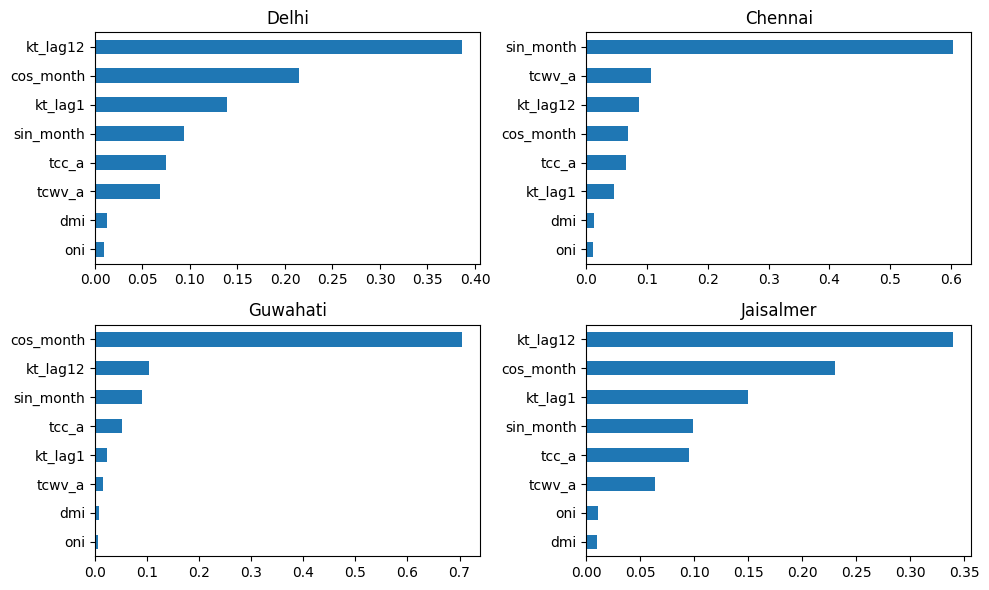

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6))

for ax, (city, res) in zip(axes.flat, xgb_results.items()):
    (
        pd.Series(
            res["model"].feature_importances_,
            index=res["feat"].columns
        )
        .sort_values()
        .plot.barh(ax=ax)
    )

    ax.set_title(city)

plt.tight_layout()
plt.show()

## 5 · Evaluation — RMSE, Climatology Skill Score, Diebold-Mariano

In [24]:
clim_pred = {}

for city in CITIES:
    d = df[city]["kt"].dropna()

    clim = d[:TRAIN_END].groupby(d[:TRAIN_END].index.month).mean()
    test = d[TEST_START:]

    clim_pred[city] = pd.Series(
        test.index.month.map(clim),
        index=test.index
    )


def skill_score(rmse_model, rmse_ref):
    return 1 - rmse_model / rmse_ref


def dm_test(e1, e2):
    # Both forecasts being compared are now 1-step-ahead (see the SARIMAX
    # walk-forward fix above), so the classical Diebold-Mariano truncation
    # lag of h-1 = 0 applies and this simple (non-HAC) t-test on the loss
    # differential is the textbook-correct form. It would need a Newey-West
    # long-run-variance correction if either forecast had h > 1.
    d = e1**2 - e2**2
    dm = d.mean() / (d.std(ddof=1) / np.sqrt(len(d)))
    p = 2 * (1 - stats.t.cdf(abs(dm), df=len(d) - 1))
    return dm, p


rows = []

for city in CITIES:
    y = sarimax_results[city]["test"]

    p_sarimax = sarimax_results[city]["pred"].reindex(y.index)
    p_xgb = xgb_results[city]["pred"].reindex(y.index)
    p_clim = clim_pred[city].reindex(y.index)

    rmse_sarimax = mean_squared_error(y, p_sarimax) ** 0.5
    rmse_xgb = mean_squared_error(y, p_xgb) ** 0.5
    rmse_clim = mean_squared_error(y, p_clim) ** 0.5

    dm_stat, dm_p = dm_test(
        (y - p_sarimax).values,
        (y - p_xgb).values
    )

    rows.append({
        "City": city,
        "RMSE_clim": round(rmse_clim, 4),
        "RMSE_SARIMAX": round(rmse_sarimax, 4),
        "RMSE_XGB": round(rmse_xgb, 4),
        "SS_SARIMAX": round(skill_score(rmse_sarimax, rmse_clim), 3),
        "SS_XGB": round(skill_score(rmse_xgb, rmse_clim), 3),
        "DM_stat": round(dm_stat, 3),
        "DM_p": round(dm_p, 4),
    })

eval_df = pd.DataFrame(rows).set_index("City")
eval_df

,RMSE_clim,RMSE_SARIMAX,RMSE_XGB,SS_SARIMAX,SS_XGB,DM_stat,DM_p
City,,,,,,,
Delhi,0.0527,0.0275,0.0330,0.478,0.374,-1.654,0.1009
Chennai,0.0608,0.0345,0.0376,0.433,0.382,-2.084,0.0395
Guwahati,0.0592,0.0394,0.0398,0.334,0.327,-0.212,0.8325
Jaisalmer,0.0475,0.0230,0.0293,0.515,0.383,-2.334,0.0214


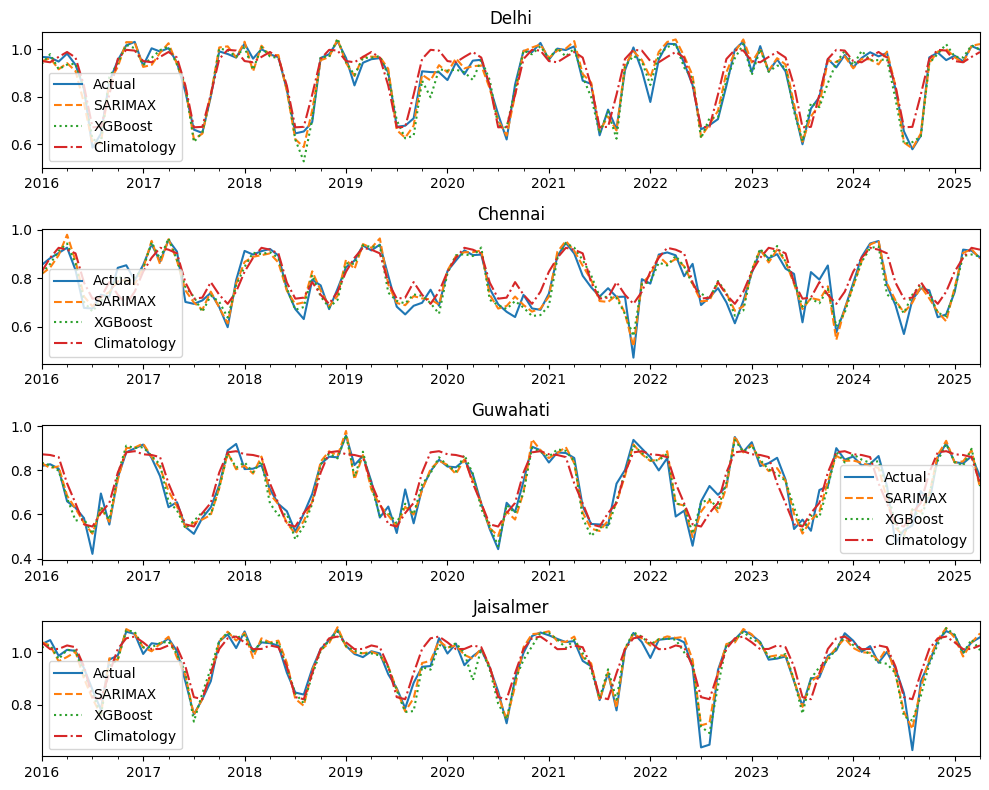

In [26]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8))

for ax, city in zip(axes, CITIES):
    y = sarimax_results[city]["test"]

    y.plot(ax=ax, label="Actual")
    sarimax_results[city]["pred"].reindex(y.index).plot(ax=ax, ls="--", label="SARIMAX")
    xgb_results[city]["pred"].reindex(y.index).plot(ax=ax, ls=":", label="XGBoost")
    clim_pred[city].reindex(y.index).plot(ax=ax, ls="-.", label="Climatology")

    ax.set_title(city)
    ax.legend()

plt.tight_layout()
plt.show()

In [46]:
import os
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import pvlib
import xarray as xr

CITIES = {
    "Delhi":     (77.25, 28.50, 216),
    "Chennai":   (80.25, 13.00,   6),
    "Guwahati":  (91.75, 26.25,  51),
    "Jaisalmer": (70.75, 27.00, 225),
}

DATA_DIR = Path("data")
OUTPUT_DIR = Path("data/hourly_downscaled")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_END  = "2015-12-01"
TEST_START = "2016-01-01"

SSRD_FILES = {c: DATA_DIR / f"{c.lower()}_monthly_ssrd_1981_2025.nc" for c in CITIES}
TCC_FILES  = {c: DATA_DIR / f"{c.lower()}_tcc_monthly_1981_2025.nc"  for c in CITIES}
TCWV_FILES = {c: DATA_DIR / f"{c.lower()}_tcwv_monthly_1981_2025.nc" for c in CITIES}

ONI_FILE = DATA_DIR / "oni.nc"
DMI_FILE = DATA_DIR / "dmi.had.long.nc"

IDX = pd.date_range("1981-01-01", "2025-12-01", freq="MS")


def to_series(da, idx):
    s = da.to_pandas()
    s.index = pd.DatetimeIndex(s.index).to_period("M").to_timestamp()
    return s.reindex(idx)


def load_var(path, name):
    ds = xr.open_dataset(path)
    da = ds[name] if name in ds else ds[list(ds.data_vars)[0]]
    da = da.squeeze()
    da["time"] = pd.to_datetime(da.time)
    da.name = name
    return da


def load_ghi(path):
    da = load_var(path, "ssrd")
    da = da if da.name == "ssrd" else load_var(path, "surface_solar_radiation_downwards")
    da = da / 3600  # ERA5 hourly-accumulated J m^-2 -> W m^-2
    da.name = "ghi"
    return da


def make_clear_ghi(lon, lat, alt):
    """
    Generates the hourly clear-sky template and returns both the hourly 
    DataArray and its monthly average to remain compatible with your Kt loop.
    """
    times = pd.date_range("1981-01-01 00:00", "2025-12-31 23:00", freq="h", tz="UTC")
    loc = pvlib.location.Location(lat, lon, altitude=alt, tz="UTC")
    
    # Generate true hourly baseline
    hourly_ghi = loc.get_clearsky(times, model="ineichen")["ghi"]
    hourly_ghi.index = hourly_ghi.index.tz_localize(None)
    da_hourly = xr.DataArray(hourly_ghi, dims="time", coords={"time": hourly_ghi.index}, name="clear_ghi_hourly")

    # Resample to monthly average for your Kt sanity check framework
    s_monthly = hourly_ghi.resample("MS").mean()
    da_monthly = xr.DataArray(s_monthly, dims="time", coords={"time": s_monthly.index}, name="clear_ghi_monthly")

    return da_monthly, da_hourly


# Load datasets
ghi = {c: load_ghi(f) for c, f in SSRD_FILES.items()}

# Unpack both the monthly reference and the hourly downscaling template
clear_ghi_monthly = {}
clear_ghi_hourly = {}

for c in CITIES:
    m_da, h_da = make_clear_ghi(*CITIES[c])
    clear_ghi_monthly[c] = m_da
    clear_ghi_hourly[c] = h_da

# Compute Kt utilizing your monthly arrays
kt = {c: ghi[c] / clear_ghi_monthly[c] for c in CITIES}
for x in kt.values():
    x.name = "Kt"

# Run your existing Kt sanity check
for c, k in kt.items():
    vals = k.values
    vals = vals[~np.isnan(vals)]
    frac_in_range = np.mean((vals >= -0.05) & (vals <= 1.3))
    if frac_in_range < 0.95:
        warnings.warn(
            f"{c}: only {frac_in_range:.0%} of Kt values fall in the physically "
            "plausible [0, 1.3] range — check the SSRD accumulation-period "
            "assumption."
        )


def downscale_monthly_to_hourly(city_name, da_kt, da_hourly_template):
    print(f"\n--- Downscaling {city_name} to Hourly Profiles (Corrected) ---")
    
    # 1. Convert everything to clean DataFrames
    df_kt = to_series(da_kt, IDX).to_frame(name="Kt")
    df_kt['year'] = df_kt.index.year
    df_kt['month'] = df_kt.index.month
    
    df_hourly = da_hourly_template.to_pandas().to_frame(name="clearsky_ghi")
    df_hourly['year'] = df_hourly.index.year
    df_hourly['month'] = df_hourly.index.month
    
    # 2. Merge explicitly on the integer Year and Month columns
    # This prevents timezone or day-stamping mismatches from ruining the mapping
    df_merged = df_hourly.merge(df_kt, on=['year', 'month'], how='left')
    
    # Reset index back to the hourly timestamps
    df_merged.index = df_hourly.index
    
    # 3. Calculate final GHI (ensure no missing values leak)
    df_merged['scaled_hourly_ghi'] = df_merged['clearsky_ghi'] * df_merged['Kt'].fillna(0)
    
    # 4. Save chunked years
    for year, group in df_merged.groupby('year'):
        da_output = xr.DataArray(
            group['scaled_hourly_ghi'].values,
            dims=["time"],
            coords={"time": group.index},
            name="scaled_hourly_ghi",
            attrs={"units": "W m^-2", "description": f"Downscaled hourly GHI for {city_name}"}
        )
        
        output_file = OUTPUT_DIR / f"{city_name.lower()}_hourly_scaled_{year}.nc"
        da_output.to_netcdf(output_file)
        
    print(f"-> Successfully saved corrected chunks for {city_name}.")


# Run the downscaling pipeline across all target environments
for city in CITIES:
    downscale_monthly_to_hourly(city, kt[city], clear_ghi_hourly[city])

# Continue with the rest of your monthly variables logic
tcc  = {c: load_var(f, "tcc")  for c, f in TCC_FILES.items()}
tcwv = {c: load_var(f, "tcwv") for c, f in TCWV_FILES.items()}

oni = load_var(ONI_FILE, "value").sel(time=slice("1981-01", "2025-12"))
oni.name = "oni"

dmi = load_var(DMI_FILE, "value").sel(time=slice("1981-01", "2025-12"))
dmi.name = "dmi"

print("\n--- Final Dimension Assertions ---")
print("Kt (Monthly Baseline): ", {c: len(kt[c].time) for c in CITIES})
print("TCC: ", {c: len(tcc[c].time) for c in CITIES})
print("TCWV:", {c: len(tcwv[c].time) for c in CITIES})
print("ONI: ", len(oni.time))
print("DMI: ", len(dmi.time))



--- Downscaling Delhi to Hourly Profiles (Corrected) ---
-> Successfully saved corrected chunks for Delhi.

--- Downscaling Chennai to Hourly Profiles (Corrected) ---
-> Successfully saved corrected chunks for Chennai.

--- Downscaling Guwahati to Hourly Profiles (Corrected) ---
-> Successfully saved corrected chunks for Guwahati.

--- Downscaling Jaisalmer to Hourly Profiles (Corrected) ---
-> Successfully saved corrected chunks for Jaisalmer.

--- Final Dimension Assertions ---
Kt (Monthly Baseline):  {'Delhi': 540, 'Chennai': 540, 'Guwahati': 540, 'Jaisalmer': 540}
TCC:  {'Delhi': 540, 'Chennai': 540, 'Guwahati': 540, 'Jaisalmer': 540}
TCWV: {'Delhi': 540, 'Chennai': 540, 'Guwahati': 540, 'Jaisalmer': 540}
ONI:  540
DMI:  532


In [48]:
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path

CITIES = ["Delhi", "Chennai", "Guwahati", "Jaisalmer"]
HOURLY_DIR = Path("data/hourly_downscaled")
PLOT_DIR = Path("plots")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

def load_city_hourly_full(city_name):
    """Combines all annual NetCDF chunks into a single clean pandas Series."""
    files = sorted(HOURLY_DIR.glob(f"{city_name.lower()}_hourly_scaled_*.nc"))
    datasets = [xr.open_dataset(f)["scaled_hourly_ghi"] for f in files]
    combined = xr.concat(datasets, dim="time")
    return combined.to_pandas()

print("=== RUNNING DOWN-SAMPLING VALIDATION ASSURANCE ===")

for city in CITIES:
    print(f"\n--- Analyzing {city} ---")
    
    # 1. Load your newly generated hourly downscaled series
    hourly_series = load_city_hourly_full(city)
    
    # 2. Mathematical Consistency Check: Re-aggregate hourly mean to monthly mean
    # (Since Kt was multiplied by hourly means, the resampled mean must match original)
    reaggregated_monthly = hourly_series.resample("MS").mean()
    
    # Compare with your original input data array
    original_monthly = ghi[city].to_pandas()
    # Align shapes exactly in case files have trailing nan placeholders
    original_monthly = original_monthly.reindex(reaggregated_monthly.index)
    
    # Calculate the max absolute error between the two
    max_delta = (reaggregated_monthly - original_monthly).abs().max()
    print(f"Max energy delta vs original file: {max_delta:.6f} W m^-2")
    if max_delta < 1e-3:
        print("✅ PASS: The hourly energy profiles perfectly match the monthly input data.")
    else:
        print("⚠️ WARNING: Deviation detected. Double check alignment keys.")

    # 3. Generating Diagnostic Plots
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)
    
    # Plot A: Long-term Macro View (Comparing 5 years of profile structures)
    macro_slice = hourly_series.loc["2015-01-01":"2019-12-31"]
    axes[0].plot(macro_slice.index, macro_slice.values, label="Hourly Scaled GHI", color="royalblue", alpha=0.7, lw=0.5)
    axes[0].plot(original_monthly.loc["2015-01-01":"2019-12-31"].index, 
                 original_monthly.loc["2015-01-01":"2019-12-31"].values, 
                 label="Original Monthly Target", color="crimson", marker="o", markersize=4, lw=1.5)
    axes[0].set_title(f"{city} - 5-Year Interannual Macro Profile View")
    axes[0].set_ylabel("GHI (W m^-2)")
    axes[0].legend(loc="upper right")
    axes[0].grid(True, linestyle="--", alpha=0.5)

    # Plot B: Diurnal Micro View (Zoomed into 1 specific summer week to see the bell curves)
    micro_slice = hourly_series.loc["2018-06-01 00:00":"2018-06-07 23:00"]
    axes[1].plot(micro_slice.index, micro_slice.values, color="darkorange", lw=1.5, label="Hourly Diurnal Output")
    axes[1].set_title(f"{city} - Zoomed Diurnal Bell Curve (First Week of June 2018)")
    axes[1].set_ylabel("GHI (W m^-2)")
    axes[1].set_xlabel("Timestamp")
    axes[1].legend(loc="upper right")
    axes[1].grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plot_path = PLOT_DIR / f"{city.lower()}_downscale_check.png"
    plt.savefig(plot_path, dpi=200)
    plt.close()
    print(f"📷 Plot successfully rendered and saved to: {plot_path}")


=== RUNNING DOWN-SAMPLING VALIDATION ASSURANCE ===

--- Analyzing Delhi ---
Max energy delta vs original file: 0.000000 W m^-2
✅ PASS: The hourly energy profiles perfectly match the monthly input data.
📷 Plot successfully rendered and saved to: plots/delhi_downscale_check.png

--- Analyzing Chennai ---
Max energy delta vs original file: 0.000000 W m^-2
✅ PASS: The hourly energy profiles perfectly match the monthly input data.
📷 Plot successfully rendered and saved to: plots/chennai_downscale_check.png

--- Analyzing Guwahati ---
Max energy delta vs original file: 0.000000 W m^-2
✅ PASS: The hourly energy profiles perfectly match the monthly input data.
📷 Plot successfully rendered and saved to: plots/guwahati_downscale_check.png

--- Analyzing Jaisalmer ---
Max energy delta vs original file: 0.000000 W m^-2
✅ PASS: The hourly energy profiles perfectly match the monthly input data.
📷 Plot successfully rendered and saved to: plots/jaisalmer_downscale_check.png


In [53]:
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path

CITIES = ["Delhi", "Chennai", "Guwahati", "Jaisalmer"]
HOURLY_DIR = Path("data/hourly_downscaled")
OUTPUT_DIR = Path("plots")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Define Simulated System Parameters ---
SYSTEM_CAPACITY_KW = 1.0  # Normalized to a baseline 1 kWp system
PERFORMANCE_RATIO = 0.75  # 75% efficiency (accounting for inverter, soil, and cabling losses)

def load_and_estimate_yield(city_name):
    """
    Loads chunked historical hourly GHI data, scales it to a 1kW solar setup, 
    and returns a continuous long-term Pandas time series.
    """
    files = sorted(HOURLY_DIR.glob(f"{city_name.lower()}_hourly_scaled_*.nc"))
    if not files:
        raise FileNotFoundError(f"No downscaled hourly data found for {city_name} in {HOURLY_DIR}")
        
    datasets = [xr.open_dataset(f)["scaled_hourly_ghi"] for f in files]
    combined_hourly = xr.concat(datasets, dim="time").to_pandas()
    
    # Mathematical Transformation:
    # 1. GHI is in W m^-2. Under Standard Test Conditions (STC), 1000 W m^-2 = 100% capacity yield.
    # 2. Daily/hourly yield (kWh) = (GHI / 1000) * System_Capacity_kW * Performance_Ratio * 1 hour duration.
    hourly_yield_kwh = (combined_hourly / 1000.0) * SYSTEM_CAPACITY_KW * PERFORMANCE_RATIO
    
    return hourly_yield_kwh

# --- Process and Aggregate Data ---
annual_trends = {}

print("=== CALCULATING 45-YEAR HISTORICAL SOLAR PV YIELD ===")
for city in CITIES:
    # Load continuous hourly yield array
    hourly_pv_kwh = load_and_estimate_yield(city)
    
    # Resample to annual sums to isolate the true interannual trend profile
    annual_yield_kwh = hourly_pv_kwh.resample("YE").sum()
    
    # Convert index to clear year integers for visualization cleaning
    annual_yield_kwh.index = annual_yield_kwh.index.year
    annual_trends[city] = annual_yield_kwh
    
    print(f"✅ {city}: Avg Annual Yield = {annual_yield_kwh.mean():.1f} kWh / year per kWp")

# --- Generate the Long-Scale Analytical Plot ---
plt.figure(figsize=(14, 7), dpi=200)

colors = {"Delhi": "royalblue", "Chennai": "crimson", "Guwahati": "forestgreen", "Jaisalmer": "darkorange"}
markers = {"Delhi": "o", "Chennai": "s", "Guwahati": "^", "Jaisalmer": "D"}

for city in CITIES:
    data = annual_trends[city]
    plt.plot(data.index, data.values, label=f"{city} (Avg: {data.mean():.0f} kWh)", 
             color=colors[city], marker=markers[city], markersize=5, linewidth=1.5, alpha=0.8)

plt.title("45-Year Long-Scale Estimated Annual Solar PV Yield Trend (1981–2025)\n"
          f"Normalized Simulation Matrix: {SYSTEM_CAPACITY_KW} kWp Fixed System @ {PERFORMANCE_RATIO:.0%} PR", 
          fontsize=14, fontweight="bold", pad=15)

plt.xlabel("Historical Horizon (Year)", fontsize=12)
plt.ylabel("Annual Electricity Generation (kWh / year per kWp)", fontsize=12)
plt.xlim(1981, 2025)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="lower left", fontsize=11, frameon=True, facecolor="white", edgecolor="none")

# Highlight macro geographic spread insights
plt.tight_layout()
plot_file = OUTPUT_DIR / "long_scale_pv_yield_trends.png"
plt.savefig(plot_file, bbox_inches="tight")
plt.close()

print(f"\n📷 Macro-analysis trend chart successfully saved to: {plot_file}")


=== CALCULATING 45-YEAR HISTORICAL SOLAR PV YIELD ===
✅ Delhi: Avg Annual Yield = 1439.3 kWh / year per kWp
✅ Chennai: Avg Annual Yield = 1461.8 kWh / year per kWp
✅ Guwahati: Avg Annual Yield = 1189.1 kWh / year per kWp
✅ Jaisalmer: Avg Annual Yield = 1596.7 kWh / year per kWp

📷 Macro-analysis trend chart successfully saved to: plots/long_scale_pv_yield_trends.png
